# Plot Raw Unaccumulated Data Over Time

In [10]:
import sys
import os
sys.path.append(os.path.abspath('..'))
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from venus_ml import VenusDataset

In [11]:
sets = ['00', '01', '02', '03', '04', '05', '06', '08', '08a', '08b', '08c', '08d', '09', '10', '10b', '11', '11b', '12', '13', '14']
requested = {
    'k18_fw': [1.4e3, 'Watts'],
    'g28_fw': [4.3e3, 'Watts'],
    'inj_i': [185, 'Amps'],
    'ext_i': [137, 'Amps'],
    'mid_i': [153, 'Amps'],
    'sext_i': [430, 'Amps'],
    'extraction_v': [20, 'kV'],
    'puller_v': [2, 'kV'],
}

In [12]:
# Instantiate the dataset
file_path = '../data/raw_watch_data.parquet'
input_columns = list(requested.keys()) + ["run_id", "time"]
output_columns = []  # Assuming there are no output columns for this task
run_selection = sets

dataset = VenusDataset(
    file_path=file_path,
    input_columns=input_columns,
    output_columns=output_columns,
    run_selection=run_selection
)
df = dataset.df

In [13]:
inputs = dataset.inputs
print(inputs[inputs['run_id'] == '00'].shape[0]//60)


3696


In [14]:
def plot_feature_over_time(feature_name, dataset):
    import matplotlib.pyplot as plt
    import matplotlib.dates as mdates
    from datetime import datetime
    import numpy as np
    
    # Get unique runs
    runs = dataset.df['run_id'].unique()
    
    # Determine number of runs
    n_runs = len(runs)
    
    # Get requested value and units for the feature
    if feature_name in requested:
        requested_value, units = requested[feature_name]
    else:
        requested_value, units = None, ''
    
    # Create subplots without shared x-axis
    fig, axs = plt.subplots(n_runs, 1, figsize=(12, 3 * n_runs), sharex=False)
    
    # Ensure axs is iterable
    if n_runs == 1:
        axs = [axs]
    
    for i, run in enumerate(runs):
        ax = axs[i]
        # Select data for the run
        run_data = dataset.df[dataset.df['run_id'] == run]
        # Sort data by unix_time
        run_data = run_data.sort_values('time')
    
        # Convert unix_time to datetime
        times = pd.to_datetime(run_data['time'], unit='s')
        feature_values = run_data[feature_name]
    
        # Calculate mean and standard deviation
        mean = feature_values.mean()
        std = feature_values.std()
    
        # Categorize data points
        deviations = (feature_values - mean).abs() / std
        within_3_sigma = deviations <= 3
        between_3_and_5_sigma = (deviations > 3) & (deviations <= 5)
        beyond_5_sigma = deviations > 5
    
        # Plot data points in different colors based on category using scatter plots
        ax.scatter(times[within_3_sigma], feature_values[within_3_sigma], s=5, label='Within ±3σ', color='blue', alpha=0.7)
        ax.scatter(times[between_3_and_5_sigma], feature_values[between_3_and_5_sigma], s=5, label='>3σ and ≤5σ', color='orange', alpha=0.7)
        ax.scatter(times[beyond_5_sigma], feature_values[beyond_5_sigma], s=5, label='>5σ', color='red', alpha=0.7)
    
        # Plot the requested value as a horizontal green dashed line
        if requested_value is not None:
            ax.axhline(y=requested_value, color='green', linestyle='--', label='Requested Value')
        
        # Plot mean and threshold lines
        ax.axhline(y=mean, color='gray', linestyle='-', label='Mean')
        
        ax.set_title(f'Run {run}')
        ax.set_ylabel(f'{feature_name} ({units})')
        ax.grid(True)
    
        # Format x-axis as dates
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M:%S'))
        # Rotate date labels for better readability
        plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
        
        # Add legend, avoiding duplicate labels
        handles, labels = ax.get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        ax.legend(by_label.values(), by_label.keys())
    
    axs[-1].set_xlabel('Time')
    
    plt.tight_layout()
    plt.show()


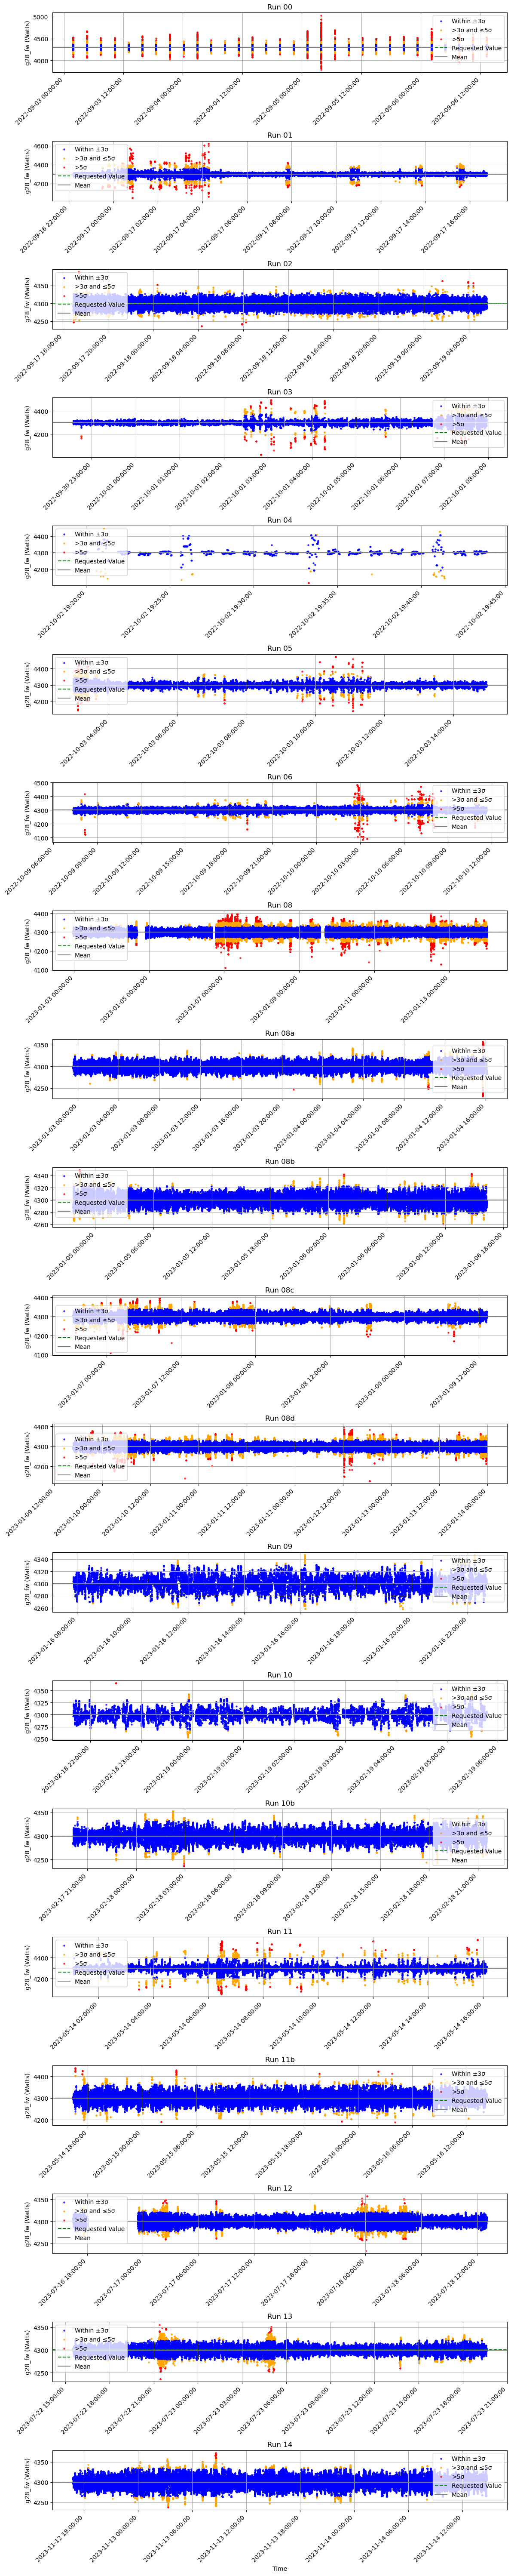

In [15]:
plot_feature_over_time('g28_fw', dataset)

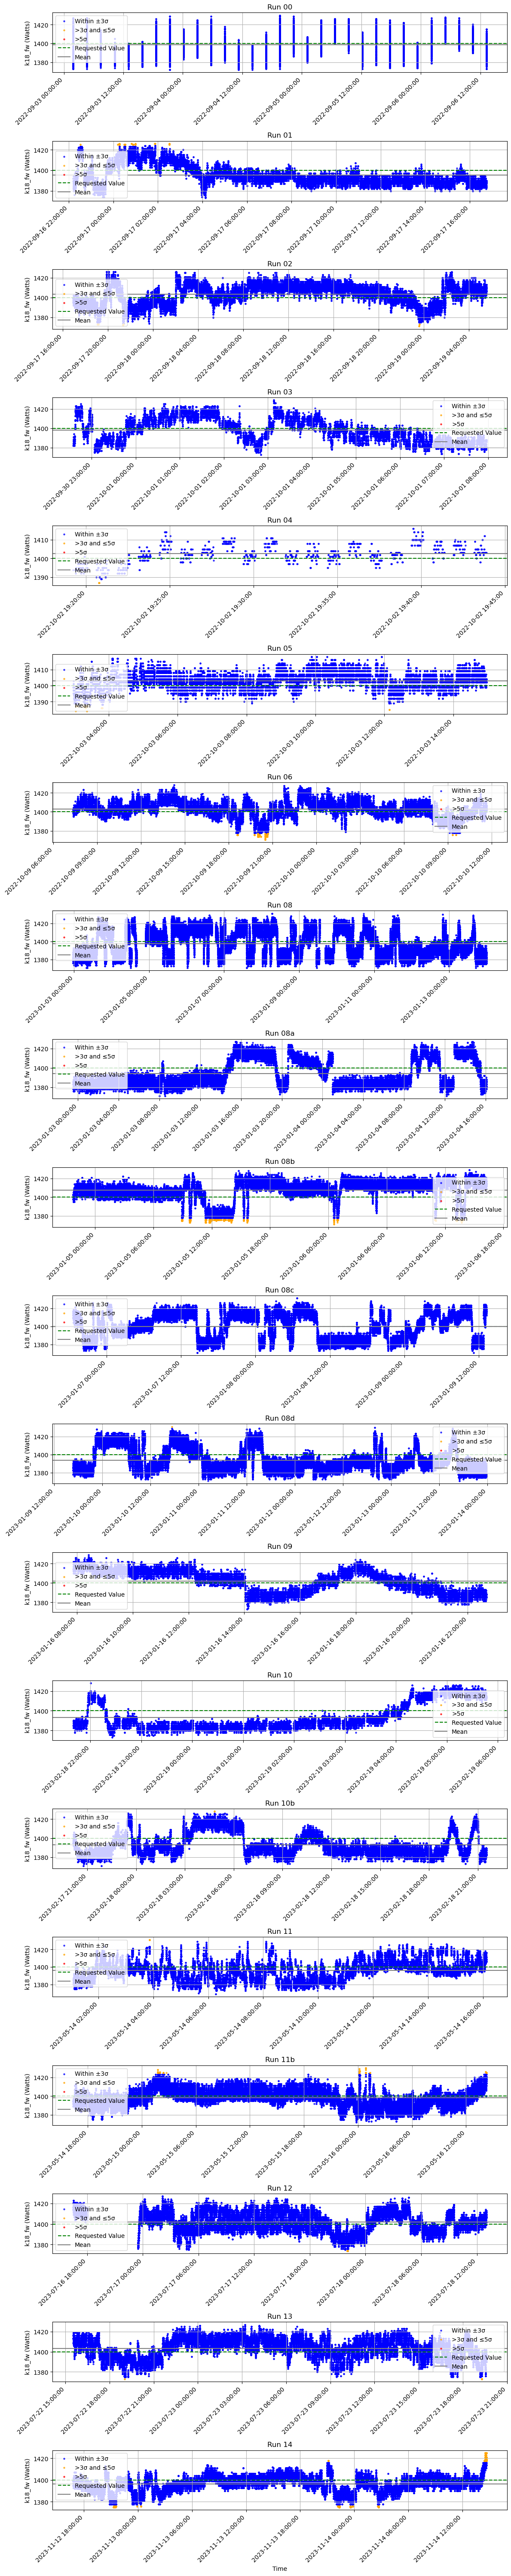

In [16]:
plot_feature_over_time('k18_fw', dataset)